<a href="https://colab.research.google.com/github/nikita082000/DTEY/blob/%D0%9A%D0%A1%D0%92%D0%94/Nikytenko_Final_Test__1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# 1) Прочитайте CSV файл
from google.colab import files
import io
import pandas as pd

files.upload()

df = pd.read_csv('Global YouTube Statistics.csv', encoding='latin-1')
df.head()

Saving Global YouTube Statistics.csv to Global YouTube Statistics (6).csv


,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [11]:
# 2) Виведіть перші п'ять рядків
print("Перші 5 рядків:")
display(df.head())

Перші 5 рядків:


,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [13]:
# 3) Виведіть розміри датасету, перевірте наявність пропусків, дублікатів
print(f"Розмір датасету: {df.shape} (рядків, стовпців)")
print("\nКількість пропусків по стовпцях:")
print(df.isna().sum())

duplicates_count = df.duplicated().sum()
print(f"\nКількість дублікатів: {duplicates_count}")

Розмір датасету: (995, 28) (рядків, стовпців)

Кількість пропусків по стовпцях:
rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year               

In [15]:
# 4) Якщо є пропуски, замінить тип даних на float і середнє значення за стовпцем
for col in df.columns:
    if df[col].isna().sum() > 0:
        converted = pd.to_numeric(df[col], errors='coerce')

        if converted.notna().sum() > 0:
            df[col] = converted.astype(float)
            mean_val = df[col].mean()
            df[col] = df[col].fillna(mean_val)
        else:
            mode_val = df[col].mode(dropna=True)
            if len(mode_val) > 0:
                df[col] = df[col].fillna(mode_val[0])
            else:
                df[col] = df[col].fillna("Unknown")

In [16]:
# 5) Ще раз перевірте кількість пропусків
print("\nПропуски після обробки:")
print(df.isna().sum())
print(f"Загальна кількість пропусків після обробки: {df.isna().sum().sum()}")


Пропуски після обробки:
rank                                       0
Youtuber                                   0
subscribers                                0
video views                                0
category                                   0
Title                                      0
uploads                                    0
Country                                    0
Abbreviation                               0
channel_type                               0
video_views_rank                           0
country_rank                               0
channel_type_rank                          0
video_views_for_the_last_30_days           0
lowest_monthly_earnings                    0
highest_monthly_earnings                   0
lowest_yearly_earnings                     0
highest_yearly_earnings                    0
subscribers_for_last_30_days               0
created_year                               0
created_month                              0
created_date                  

In [17]:
# 6) Перевірте, скільки унікальних країн у колонці "Country"
if 'Country' in df.columns:
    unique_countries = df['Country'].nunique(dropna=True)
    print(f"\nКількість унікальних країн у 'Country': {unique_countries}")
else:
    print("\nКолонка 'Country' не знайдена у датасеті.")



Кількість унікальних країн у 'Country': 49


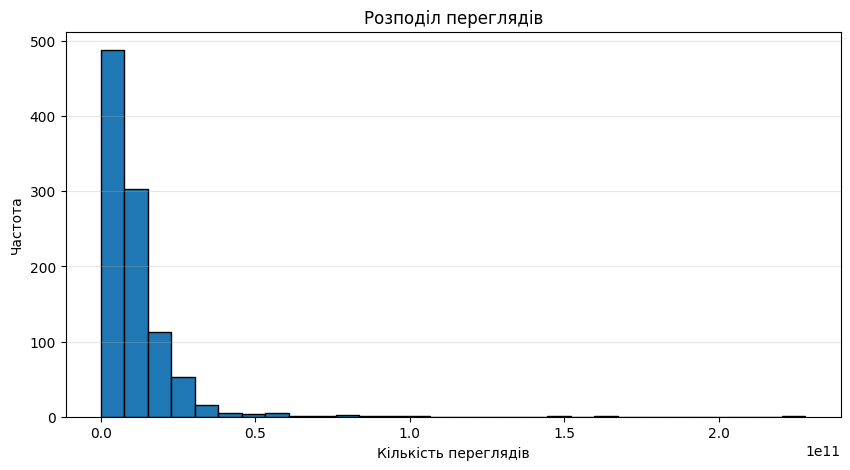

In [18]:
# 7) Побудуйте діаграму розподілу переглядів (kind='hist')
views_col = None

for c in df.columns:
    if c.strip().lower() in ['video views', 'views', 'video_views']:
        views_col = c
        break
if views_col is not None:
    df[views_col] = pd.to_numeric(df[views_col], errors='coerce')

    plt.figure(figsize=(10, 5))
    df[views_col].plot(kind='hist', bins=30, edgecolor='black')
    plt.title('Розподіл переглядів')
    plt.xlabel('Кількість переглядів')
    plt.ylabel('Частота')
    plt.grid(axis='y', alpha=0.3)
    plt.show()
else:
    print("\nКолонка для переглядів не знайдена (очікувалась 'video views').")

In [19]:
#8) Максимальна, мінімальна, середня кількість переглядів
if views_col is not None:
    max_views = df[views_col].max()
    min_views = df[views_col].min()
    mean_views = df[views_col].mean()

    print("\nСтатистика переглядів:")
    print(f"Максимальна кількість переглядів: {max_views}")
    print(f"Мінімальна кількість переглядів: {min_views}")
    print(f"Середня кількість переглядів: {mean_views:.2f}")


Статистика переглядів:
Максимальна кількість переглядів: 228000000000.0
Мінімальна кількість переглядів: 0.0
Середня кількість переглядів: 11039537052.04


In [22]:
# 10) Знайти відео/канал з найбільшою та найменшою кількістю uploads
name_col = None
for c in df.columns:
    if c.strip().lower() in ['youtuber', 'title', 'channel name', 'channel_name']:
        name_col = c
        break
if 'uploads' in df.columns and name_col is not None:
    df['uploads'] = pd.to_numeric(df['uploads'], errors='coerce')

    max_idx = df['uploads'].idxmax()
    min_idx = df['uploads'].idxmin()

    print("\nМаксимум uploads:")
    print(f"{name_col}: {df.loc[max_idx, name_col]}")
    print(f"uploads: {df.loc[max_idx, 'uploads']}")

    print("\nМінімум uploads:")
    print(f"{name_col}: {df.loc[min_idx, name_col]}")
    print(f"uploads: {df.loc[min_idx, 'uploads']}")


Максимум uploads:
Youtuber: ABP NEWS
uploads: 301308

Мінімум uploads:
Youtuber: Music
uploads: 0
